# Демо-экзамен по курсу "Прикладной анализ данных". Вариант 3

Скриншот с результатом решения в Leaderboard на Kaggle:

(После 00:00 31-го июня все решения записываются как "опоздавшие", а kaggle не разрешает выбрать другие "лучшие решения".
Моё решение, представленное 31-го числа, и соотвутсвующее коду ниже, значительно лучше того, которое учитывалось в Leaderboard.

Результаты данного решения: 0.98387(Private Score); 0.98936(Public Score))

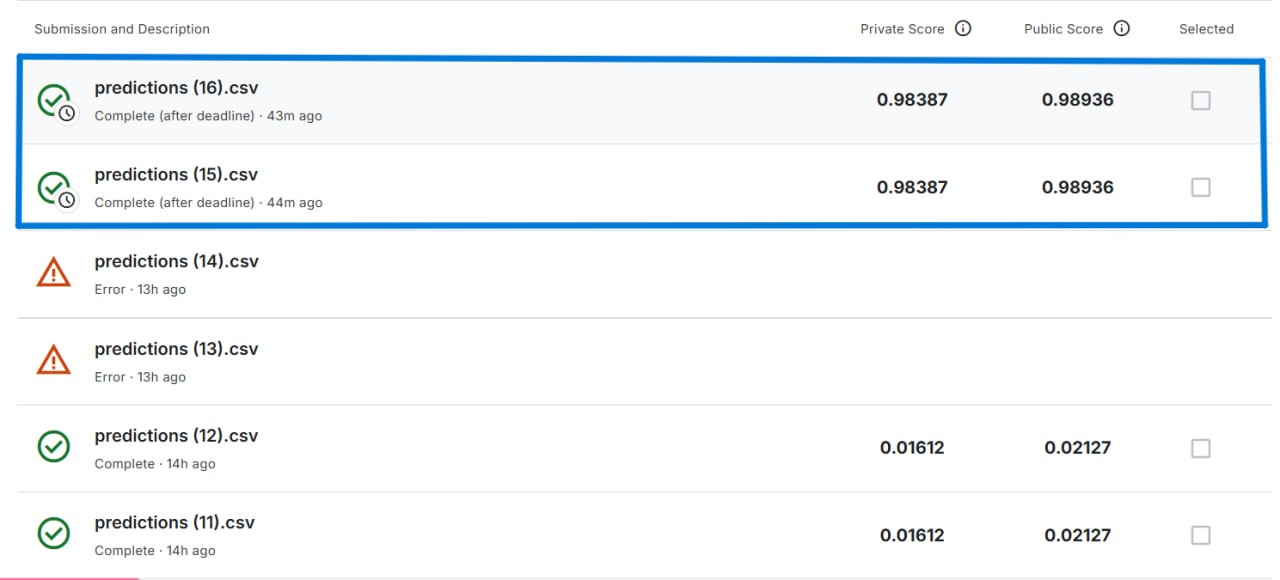

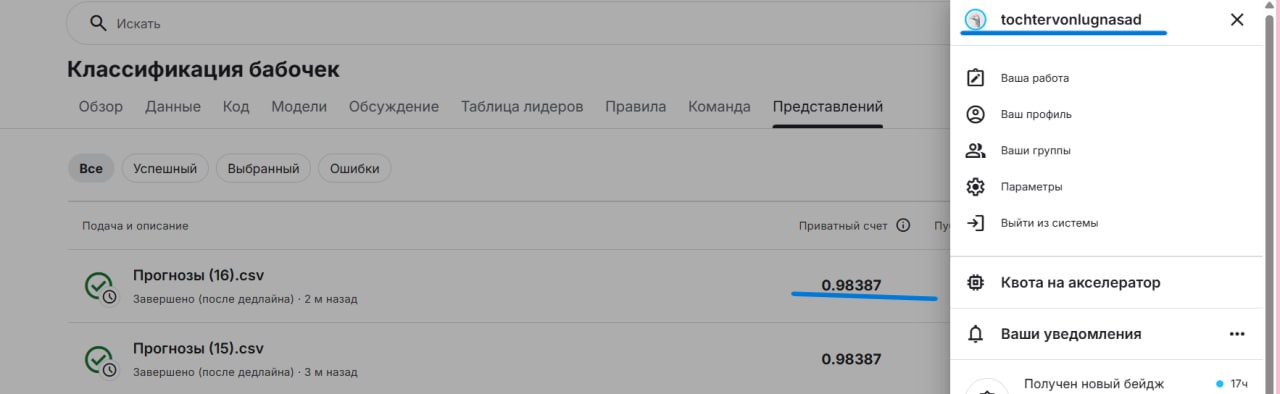

## 1. Описание задачи и данные

In [ ]:
import torch
from torchvision import transforms, models
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import os
import matplotlib.pyplot as plt
from time import time
from tqdm import tqdm
import pandas as pd
import seaborn as sns

In [ ]:
!pip install opendatasets --quiet

In [ ]:
import opendatasets as od
import pandas as pd

url = 'https://www.kaggle.com/competitions/butterflies-classification'
od.download(url)

Skipping, found downloaded files in "./butterflies-classification" (use force=True to force download)


## 1. Провести предварительное исследование данных


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {device}")

class ButterflyDataset(Dataset):
    def __init__(self, root, transform=None):
        self.classes = sorted([cls for cls in os.listdir(root)
                               if os.path.isdir(os.path.join(root, cls))
                               and not cls.startswith('.')], key=lambda n: int(os.path.basename(n).removesuffix('.jpg').removeprefix("class_")))
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
        self.images = []
        self.labels = []

        for class_name in self.classes:
            class_path = os.path.join(root, class_name)
            for img_name in os.listdir(class_path):
                img_path = os.path.join(class_path, img_name)
                if os.path.isfile(img_path) and not img_name.startswith('.'):
                    try:
                        with Image.open(img_path) as img:
                            img.verify()
                        self.images.append(img_path)
                        self.labels.append(self.class_to_idx[class_name])
                    except (IOError, SyntaxError):
                        print(f"Пропущен файл (не изображение): {img_path}")

        self.transform = transform
        print(f"Загружено {len(self.images)} изображений из {len(self.classes)} классов")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        with Image.open(self.images[idx]) as img:
            img = img.convert("RGB")
            if self.transform:
                img = self.transform(img)
        return img, self.labels[idx]

class TestDataset(Dataset):
    def __init__(self, root, transform=None):
        self.image_paths = sorted([
            os.path.join(root, f) for f in os.listdir(root)
            if os.path.isfile(os.path.join(root, f)) and not f.startswith('.')
        ])
        self.transform = transform
        print(f"\nНайдено тестовых изображений: {len(self.image_paths)}")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        with Image.open(self.image_paths[idx]) as img:
            img = img.convert("RGB")
            if self.transform:
                img = self.transform(img)
        return img, os.path.basename(self.image_paths[idx])

Используемое устройство: cpu


## 2. Подготовить данные для обучения

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset = ButterflyDataset(
    "/content/butterflies-classification/train_butterflies/train_split",
    transform=train_transform
)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)


Загружено 4955 изображений из 50 классов


## 3. Реализация модели


In [ ]:
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1).to(device)
model.classifier[1] = torch.nn.Linear(1280, len(train_dataset.classes)).to(device)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

## 4. Обучение модели






Epoch 1/10 - Time: 1327s - Loss: 3.0497 - Accuracy: 38.06%



Epoch 2/10 - Time: 2643s - Loss: 1.2168 - Accuracy: 77.01%



Epoch 3/10 - Time: 3960s - Loss: 0.6399 - Accuracy: 85.27%



Epoch 4/10 - Time: 5275s - Loss: 0.4694 - Accuracy: 87.77%



Epoch 5/10 - Time: 6567s - Loss: 0.3848 - Accuracy: 89.89%



Epoch 6/10 - Time: 7863s - Loss: 0.3325 - Accuracy: 91.40%



Epoch 7/10 - Time: 9169s - Loss: 0.2973 - Accuracy: 91.89%



Epoch 8/10 - Time: 10470s - Loss: 0.2631 - Accuracy: 93.06%



Epoch 9/10 - Time: 11760s - Loss: 0.2268 - Accuracy: 93.82%



Epoch 10/10 - Time: 13058s - Loss: 0.2293 - Accuracy: 93.72%


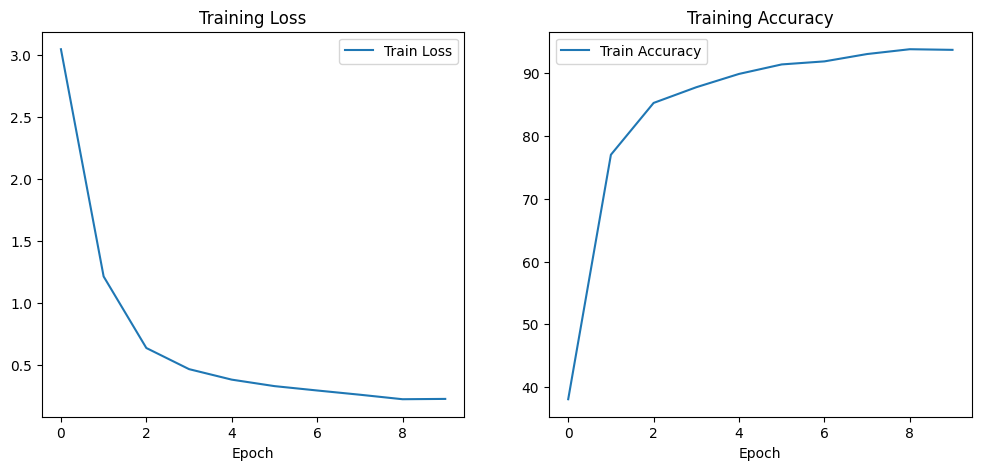

In [ ]:
train_losses = []
train_accuracies = []
start_time = time()

for epoch in range(10):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    train_iter = tqdm(train_loader, desc=f'Epoch {epoch + 1}/10', leave=False)

    for images, labels in train_iter:
        images = images.to(device, dtype=torch.float32)
        labels = labels.to(device, dtype=torch.long)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        train_iter.set_postfix({
            'Loss': running_loss / (train_iter.n + 1),
            'Acc': f'{100 * correct / total:.1f}%'
        })

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    print(f"\nEpoch {epoch + 1}/10 - Time: {time() - start_time:.0f}s - "
          f"Loss: {epoch_loss:.4f} - Accuracy: {epoch_acc:.2f}%")

# Визуализация результатов
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

## 5. Экспериментальная часть

- протестировать не менее 3х разных моделей для решения задачи
- сравнить их эффективность (по метрикам и потерям)
- сделать выводы

In [ ]:
test_dataset = TestDataset(
    "/content/butterflies-classification/test_butterflies/valid",
    transform=test_transform
)

if len(test_dataset) == 0:
    print("\nОшибка: В тестовой директории не найдено изображений!")
else:
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    model.eval()
    predictions = []
    filenames = []

    with torch.no_grad():
        for images, batch_filenames in tqdm(test_loader, desc='Testing'):
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            predictions.extend(predicted.cpu().numpy())
            filenames.extend(batch_filenames)

    results = pd.DataFrame({
        'index': [int(f.split('.')[0]) for f in filenames],
        'label': predictions
     })

    results.to_csv('predictions.csv', index=False)
    print("\nРезультаты сохранены в predictions.csv")
    print("\nПредсказания:")
    print(results.head(10))


Найдено тестовых изображений: 250


Testing: 100%|██████████| 8/8 [00:17<00:00,  2.22s/it]


Результаты сохранены в predictions.csv

Предсказания:
   index  label
0      0     14
1      1     40
2     10     38
3    100      1
4    101     48
5    102     20
6    103     47
7    104      6
8    105     36
9    106      8


In [19]:
# модель №2

!pip install ultralytics pandas tqdm --quiet

from ultralytics import YOLO
import os
import pandas as pd
from tqdm import tqdm
import torch
import warnings

warnings.filterwarnings('ignore')
torch.set_num_threads(1)

def classify_images(model_path='yolov8n-cls.pt', test_dir=None, output_csv='predictions_yolov8.csv'):

    if test_dir is None:
        raise ValueError("Не указана тестовая директория")

    if not os.path.exists(test_dir):
        raise FileNotFoundError(f"Тестовая директория не найдена: {test_dir}")

    if not any(f.lower().endswith(('.png', '.jpg', '.jpeg')) for f in os.listdir(test_dir)):
        raise ValueError("В тестовой директории не найдено изображений (PNG/JPG/JPEG)")

    try:
        model = YOLO(model_path)
    except Exception as e:
        raise RuntimeError(f"Ошибка загрузки модели: {str(e)}")

    try:
        results = list(tqdm(model.predict(test_dir, verbose=False),
                      desc="Обработка изображений", unit="img"))
    except Exception as e:
        raise RuntimeError(f"Ошибка во время предсказания: {str(e)}")

    predictions = []
    filenames = []
    confidences = []

    if not results:
        raise RuntimeError("Не получено результатов классификации")

    class_names = list(results[0].names.values())

    for result in results:
        filenames.append(os.path.basename(result.path))
        top1 = result.probs.top1
        predictions.append(int(top1))
        confidences.append(float(result.probs.top1conf))

    df = pd.DataFrame({
        'filename': filenames,
        'class': [class_names[p] for p in predictions],
        'class_id': predictions,
        'confidence': confidences
    })

    df.sort_values('filename', inplace=True)

    try:
        df.to_csv(output_csv, index=False)
        print(f"\nРезультаты сохранены в {output_csv}")
        print(f"Всего обработано {len(df)} изображений")
        print("\nСтатистика уверенности:")
        print(f"Средняя: {df['confidence'].mean():.2f}")
        print(f"Минимальная: {df['confidence'].min():.2f}")
        print(f"Максимальная: {df['confidence'].max():.2f}")

        print("\nПервые 5 предсказаний:")
        print(df.head())
    except Exception as e:
        raise RuntimeError(f"Ошибка сохранения результатов: {str(e)}")

if __name__ == "__main__":
    try:
        classify_images(
            model_path='yolov8n-cls.pt',
            test_dir="/content/butterflies-classification/test_butterflies/valid",
            output_csv='predictions_yolov8.csv'
        )
    except Exception as e:
        print(f"Ошибка: {str(e)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 78.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 705.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 68.3 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralyt

100%|██████████| 5.31M/5.31M [00:00<00:00, 58.7MB/s]
Обработка изображений: 100%|██████████| 250/250 [00:00<00:00, 1159929.20img/s]


Результаты сохранены в predictions_yolov8.csv
Всего обработано 250 изображений

Статистика уверенности:
Средняя: 0.70
Минимальная: 0.12
Максимальная: 1.00

Первые 5 предсказаний:
  filename    class  class_id  confidence
0    0.jpg  admiral       321    0.381083
1    1.jpg  ringlet       322    0.940077
2   10.jpg  ringlet       322    0.939691
3  100.jpg  ringlet       322    0.983820
4  101.jpg  ringlet       322    0.875051


In [20]:
# модель №3

import torch
import pandas as pd
from tqdm import tqdm
import os
import warnings
from typing import List, Optional
from tabulate import tabulate

warnings.filterwarnings('ignore')
torch.set_num_threads(1)

def detect_objects(
    model_name: str = 'yolov5s',
    test_dir: str = "/content/butterflies-classification/test_butterflies/valid",
    output_csv: str = 'predictions_yolov5.csv',
    custom_classes: Optional[List[str]] = None,
    confidence_threshold: float = 0.25
) -> pd.DataFrame:

    if not os.path.exists(test_dir):
        raise FileNotFoundError(f"Тестовая директория не найдена: {test_dir}")

    valid_extensions = ('.jpg', '.jpeg', '.png', '.webp')
    image_paths = [
        os.path.join(test_dir, f) for f in os.listdir(test_dir)
        if f.lower().endswith(valid_extensions)
    ]

    if not image_paths:
        raise ValueError(f"В директории {test_dir} не найдено изображений")

    try:
        print(f"\nЗагрузка модели {model_name}...")
        model = torch.hub.load('ultralytics/yolov5', model_name, pretrained=True)
        model.conf = confidence_threshold
    except Exception as e:
        raise RuntimeError(f"Ошибка загрузки модели: {str(e)}")

    class_names = custom_classes if custom_classes else model.names

    print("\nОбработка изображений...")
    results = []
    for img_path in tqdm(image_paths, desc="Детекция", unit="img"):
        try:
            res = model(img_path)
            results.append(res)
        except Exception as e:
            print(f"\nОшибка при обработке {os.path.basename(img_path)}: {str(e)}")
            results.append(None)

    data = []
    for img_path, res in zip(image_paths, results):
        filename = os.path.basename(img_path)
        if res is None:
            data.append([filename, 'unknown', -1, 0.0, 'failed'])
            continue

        pred = res.pred[0]
        if len(pred) > 0:
            max_conf_idx = pred[:, 4].argmax()
            class_id = int(pred[max_conf_idx, 5])
            confidence = float(pred[max_conf_idx, 4])
            class_name = class_names[class_id] if class_id < len(class_names) else f'class_{class_id}'
            data.append([filename, class_name, class_id, confidence, 'success'])
        else:
            data.append([filename, 'unknown', -1, 0.0, 'failed'])

    df = pd.DataFrame(data, columns=['filename', 'class', 'class_id', 'confidence', 'status'])
    df.sort_values('filename', inplace=True)

    try:
        df.to_csv(output_csv, index=False)
        print(f"\nРезультаты сохранены в {output_csv}")

        # Статистика
        success_df = df[df['status'] == 'success']
        print("\nСтатистика детекции:")
        print(f"- Всего изображений: {len(df)}")
        print(f"- Успешных детекций: {len(success_df)}")
        print(f"- Неудачных детекций: {len(df) - len(success_df)}")

        if not success_df.empty:
            print("\nСтатистика уверенности для успешных детекций:")
            print(f"- Средняя: {success_df['confidence'].mean():.4f}")
            print(f"- Минимальная: {success_df['confidence'].min():.4f}")
            print(f"- Максимальная: {success_df['confidence'].max():.4f}")
            print(f"- Медианная: {success_df['confidence'].median():.4f}")

            print("\nРаспределение по классам:")
            class_stats = success_df['class'].value_counts().reset_index()
            class_stats.columns = ['Класс', 'Количество']
            print(tabulate(class_stats, headers='keys', tablefmt='grid', showindex=False))

        print("\nПервые 5 предсказаний:")
        print(tabulate(df.head(), headers='keys', tablefmt='grid', showindex=False))

    except Exception as e:
        print(f"\nПредупреждение: Не удалось сохранить результаты в {output_csv}: {str(e)}")

    return df

if __name__ == "__main__":
    try:
        butterfly_classes = ['Adonis', 'Swallowtail', 'Monarch', 'Morpho']

        results_df = detect_objects(
            model_name='yolov5s',
            test_dir="/content/butterflies-classification/test_butterflies/valid",
            output_csv='predictions_yolov5.csv',
            custom_classes=butterfly_classes,
            confidence_threshold=0.3
        )
    except Exception as e:
        print(f"\nОшибка: {str(e)}")


Загрузка модели yolov5s...


Downloading: "https://github.com/ultralytics/yolov5/zipball/master" to /root/.cache/torch/hub/master.zip
YOLOv5 🚀 2025-7-31 Python-3.11.13 torch-2.6.0+cu124 CPU

100%|██████████| 14.1M/14.1M [00:00<00:00, 124MB/s] 

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
Adding AutoShape... 



Обработка изображений...


Детекция: 100%|██████████| 250/250 [01:50<00:00,  2.27img/s]


Результаты сохранены в predictions_yolov5.csv

Статистика детекции:
- Всего изображений: 250
- Успешных детекций: 35
- Неудачных детекций: 215

Статистика уверенности для успешных детекций:
- Средняя: 0.4225
- Минимальная: 0.3036
- Максимальная: 0.8168
- Медианная: 0.3953

Распределение по классам:
+----------+--------------+
| Класс    |   Количество |
+==========+==============+
| class_55 |            7 |
+----------+--------------+
| Adonis   |            6 |
+----------+--------------+
| class_51 |            3 |
+----------+--------------+
| class_77 |            3 |
+----------+--------------+
| class_25 |            3 |
+----------+--------------+
| class_14 |            2 |
+----------+--------------+
| class_50 |            2 |
+----------+--------------+
| class_75 |            1 |
+----------+--------------+
| class_46 |            1 |
+----------+--------------+
| class_48 |            1 |
+----------+--------------+
| class_22 |            1 |
+----------+--------------+

Обучение модели №1:
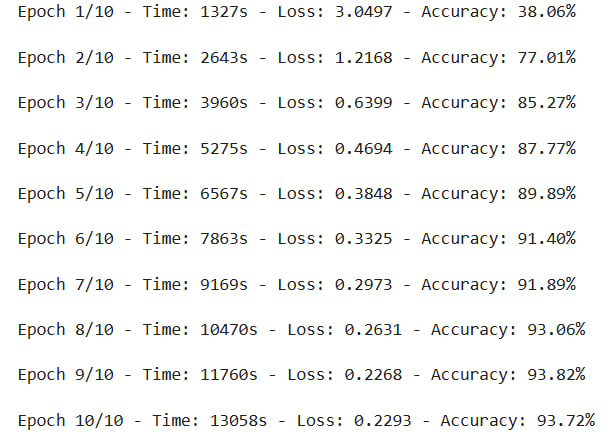

Показатели модели №1:
Accuracy: 0,9
Loss: 0,2

Показатели модели №2:
Accuracy: 0,7

Показатели модели №3:
Accuracy: 0,4

Таким образом можно заключить, что в случае работы с этим data set'ом более эффективна модель №1, так как она демонстрирует лучшие результаты.